# Laboratorio 3 — Deep Learning: Reconocimiento de Lenguaje de Señas (ASL)
### CC3084 Data Science · UVG · Semestre II 2026

**Entrega:** Avance (pasaporte) — *Análisis Exploratorio, Preprocesamiento y Selección de modelos.*

**Integrantes del grupo:**
- Nicolas Concua — 23197
- Felipe Aguilar — 23195

---

## Contexto — SignBridge

**SignBridge** es una startup guatemalteca de tecnología inclusiva que desarrolla un
traductor de **Lenguaje de Señas Americano (ASL)** en tiempo real para apps educativas.
Como equipo de Data Science, construimos y evaluamos el primer prototipo del motor de
reconocimiento: un **clasificador de letras del alfabeto ASL** a partir de fotografías de
manos. El objetivo del producto es reconocer, **letra por letra**, las señas que hace una
persona frente a una cámara.

Trabajamos con el dataset **ASL Alphabet** de Kaggle
([grassknoted/asl-alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)):
fotografías reales `.jpg` de **200×200 px a color**, organizadas en carpetas por clase.
Contiene ~87,000 imágenes en **29 clases**: las 26 letras (A–Z) más `SPACE`, `DELETE` y
`NOTHING`.

> **Alcance de este avance.** Este cuaderno cubre los ejercicios **1 (ejemplos y
> variabilidad)**, **2 (análisis exploratorio)** y **3 (preprocesamiento)**, más la
> **selección de modelos y el plan** para el procesamiento de imágenes. El entrenamiento
> de los modelos (ejercicios 4–9) queda para la entrega final.


## 0. Instalación de dependencias

Si te falta alguna librería, **descomenta y ejecuta** la siguiente celda. El notebook está
pensado para correr en un entorno con **Python 3.13** (TensorFlow todavía no publica ruedas
para 3.14). Recomendado: crear un `.venv` propio para el Lab 3.


In [1]:
# Descomenta si necesitas instalar las dependencias en tu entorno (kernel Python 3.13):
# %pip install numpy pandas matplotlib seaborn scikit-learn scipy pillow
# %pip install tensorflow            # se usa en la entrega final (modelos CNN)

## 1. Configuración: imports, semillas y rutas

Fijamos las semillas para que el muestreo de imágenes y las particiones sean
**reproducibles**, y detectamos automáticamente la carpeta del dataset.


In [2]:
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Localizar la carpeta de entrenamiento del dataset ASL ---
# Estructura esperada:  data/asl-alphabet/asl_alphabet_train/asl_alphabet_train/<CLASE>/*.jpg
CANDIDATOS = [
    "../data/asl-alphabet/asl_alphabet_train/asl_alphabet_train",
    "data/asl-alphabet/asl_alphabet_train/asl_alphabet_train",
    "../data/asl_alphabet_train/asl_alphabet_train",
]
TRAIN_DIR = next((p for p in CANDIDATOS if os.path.isdir(p)), None)
assert TRAIN_DIR is not None, (
    "No se encontró la carpeta de entrenamiento. Descarga el dataset ASL Alphabet de "
    "Kaggle y colócalo en Lab3-DataScience/data/  (ver .gitignore: data/ no se versiona)."
)

CLASES = sorted(os.listdir(TRAIN_DIR))
CLASES = [c for c in CLASES if os.path.isdir(os.path.join(TRAIN_DIR, c))]
print(f"Carpeta de datos : {TRAIN_DIR}")
print(f"Clases detectadas: {len(CLASES)}")
print(CLASES)

Carpeta de datos : ../data/asl-alphabet/asl_alphabet_train/asl_alphabet_train
Clases detectadas: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 2. Ejercicio 1 — Ejemplos del alfabeto ASL y variabilidad intra-clase

Mostramos varias muestras de **6 letras distintas**. Cada **fila** es una letra y cada
**columna** una foto diferente de esa misma seña, para observar la **variabilidad dentro de
una clase**: cambios de iluminación, encuadre, distancia de la mano y fondo, aun cuando la
seña es la misma.


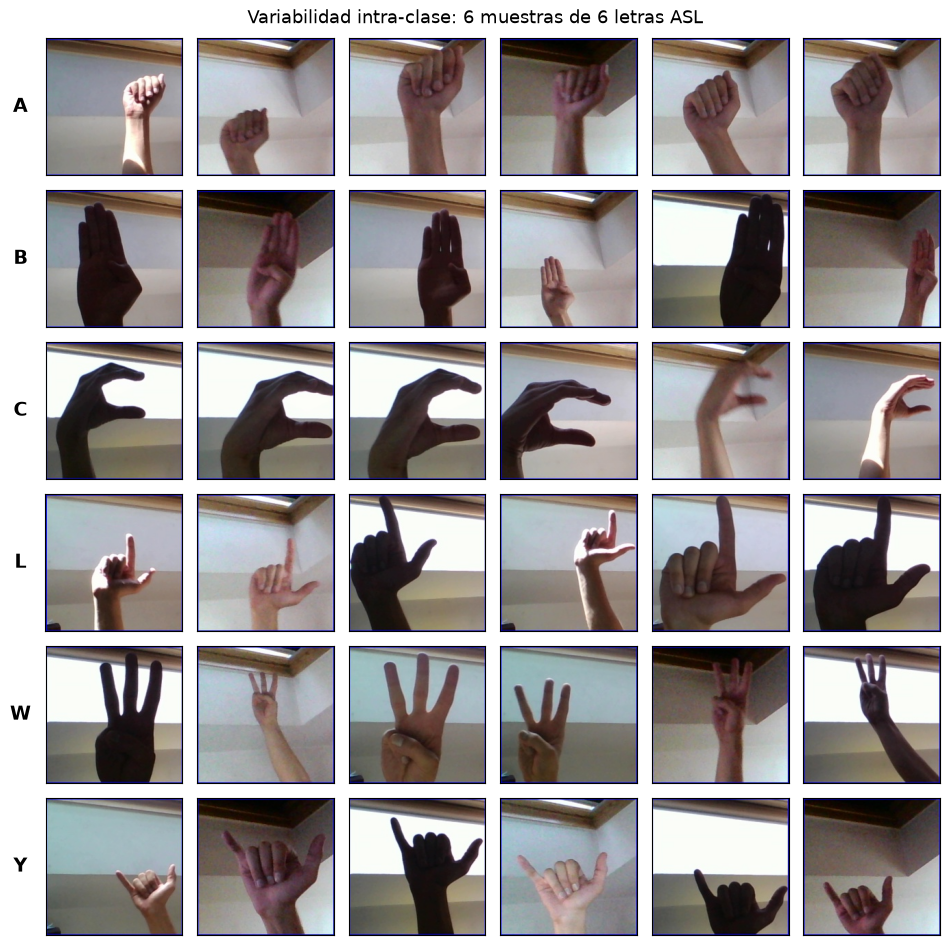

In [3]:
def cargar_muestras(clase, n, semilla=SEED):
    # Devuelve n rutas de imagenes al azar (reproducible) para una clase.
    # El offset por clase es su indice en CLASES (deterministico entre corridas).
    carpeta = os.path.join(TRAIN_DIR, clase)
    archivos = sorted(f for f in os.listdir(carpeta) if f.lower().endswith(".jpg"))
    rng = random.Random(semilla + CLASES.index(clase))
    elegidos = rng.sample(archivos, min(n, len(archivos)))
    return [os.path.join(carpeta, f) for f in elegidos]

LETRAS_DEMO = ["A", "B", "C", "L", "W", "Y"]   # 6 letras visualmente distintas
N_MUESTRAS = 6

fig, axes = plt.subplots(len(LETRAS_DEMO), N_MUESTRAS,
                         figsize=(N_MUESTRAS * 1.6, len(LETRAS_DEMO) * 1.6))
for i, letra in enumerate(LETRAS_DEMO):
    rutas = cargar_muestras(letra, N_MUESTRAS)
    for j, ruta in enumerate(rutas):
        ax = axes[i, j]
        ax.imshow(Image.open(ruta))
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(letra, rotation=0, labelpad=18, fontsize=14,
                          va="center", fontweight="bold")
fig.suptitle("Variabilidad intra-clase: 6 muestras de 6 letras ASL", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación.** Dentro de una misma letra las fotos **no son idénticas**: varía la
iluminación (manos más claras u oscuras), la posición y el tamaño de la mano en el encuadre,
y ligeras rotaciones de la muñeca. El fondo, en cambio, es bastante **constante** (pared
clara) — una pista de que el modelo podría apoyarse en el fondo en lugar de la mano, algo a
vigilar. Esta variabilidad es justo lo que un clasificador robusto debe aprender a ignorar
para quedarse con la **forma de la mano**, que es lo que define la seña.


## 3. Ejercicio 2 — Análisis exploratorio de los datos

Guiamos el análisis con **preguntas** sobre lo que nos interesa entender del dataset antes
de modelar:

1. ¿Qué **resolución y formato** tienen las imágenes? ¿Son todas iguales?
2. ¿Está **balanceado** el dataset entre las 29 clases?
3. ¿Qué letras **se confunden visualmente** entre sí (p. ej. M/N/S, U/V/R)?
4. ¿Cómo definimos nuestro propio conjunto de **entrenamiento / validación / prueba**?


### 3.1 ¿Qué resolución y formato tienen las imágenes?

Recorremos una **muestra de 30 imágenes por clase** (870 en total) y registramos su tamaño,
modo de color, formato de archivo y peso en disco. Muestrear en vez de abrir las 87,000 es
suficiente para caracterizar el dataset y mucho más rápido; si hubiera imágenes "raras"
(otro tamaño o en escala de grises) aparecerían en la muestra.


In [4]:
registros = []
for clase in CLASES:
    for ruta in cargar_muestras(clase, 30):
        with Image.open(ruta) as im:
            registros.append({
                "clase": clase,
                "ancho": im.size[0], "alto": im.size[1],
                "modo": im.mode, "formato": im.format,
                "peso_kb": os.path.getsize(ruta) / 1024,
            })
meta = pd.DataFrame(registros)
print(f"Imágenes inspeccionadas: {len(meta)}")
print("\nTamaños (ancho x alto) encontrados:")
print(meta.groupby(["ancho", "alto"]).size().rename("conteo"))
print("\nModos de color:", meta["modo"].unique().tolist())
print("Formatos       :", meta["formato"].unique().tolist())
print("\nPeso en disco (KB):")
print(meta["peso_kb"].describe()[["min", "mean", "max"]].round(1))

Imágenes inspeccionadas: 870

Tamaños (ancho x alto) encontrados:
ancho  alto
200    200     870
Name: conteo, dtype: int64

Modos de color: ['RGB']
Formatos       : ['JPEG']

Peso en disco (KB):
min      8.8
mean    12.4
max     15.1
Name: peso_kb, dtype: float64


**Hallazgo.** Todas las imágenes de la muestra son **200×200 px**, en modo **RGB** (3
canales de color) y formato **JPEG**, con un peso muy homogéneo (~11–12 KB). No hay imágenes
en escala de grises, con canal alfa ni de tamaños distintos: el dataset es **uniforme**, lo
que simplifica el preprocesamiento (no hará falta normalizar tamaños ni convertir modos, solo
redimensionar para aligerar el cómputo).


### 3.2 ¿Está balanceado el dataset? Distribución de clases

Contamos **todas** las imágenes de cada clase (esto es rápido: solo listamos archivos, no
los abrimos).


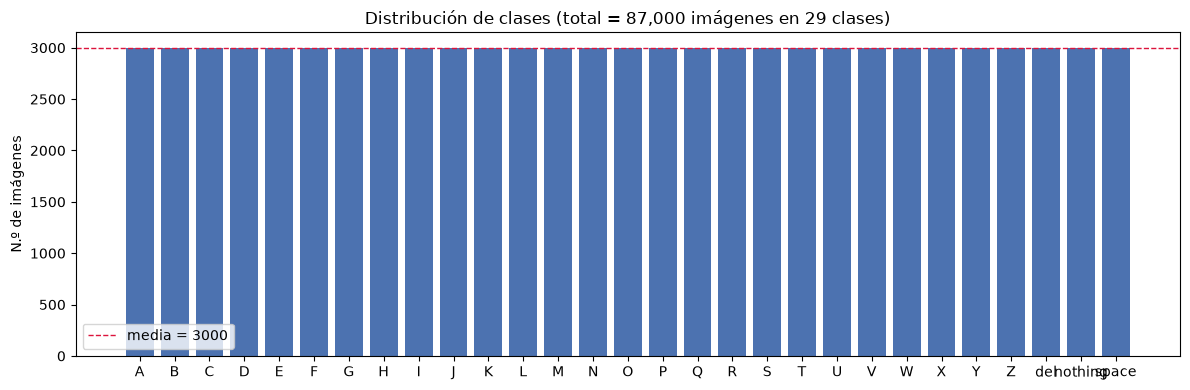

Imágenes por clase: 3000 a 3000
¿Perfectamente balanceado? True


In [5]:
conteos = {c: len([f for f in os.listdir(os.path.join(TRAIN_DIR, c))
                    if f.lower().endswith(".jpg")]) for c in CLASES}
dist = pd.Series(conteos).sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(dist.index, dist.values, color="#4C72B0")
ax.set_ylabel("N.º de imágenes")
ax.set_title(f"Distribución de clases (total = {dist.sum():,} imágenes en {len(dist)} clases)")
ax.axhline(dist.mean(), color="crimson", ls="--", lw=1, label=f"media = {dist.mean():.0f}")
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Imágenes por clase:", dist.min(), "a", dist.max())
print("¿Perfectamente balanceado?", bool(dist.nunique() == 1))

**Hallazgo.** El dataset está **perfectamente balanceado**: exactamente **3,000
imágenes por clase** en las 29 clases (87,000 en total). Esto es una ventaja importante —
no habrá que aplicar técnicas de re-balanceo (oversampling, class weights) y la **exactitud
(accuracy)** será una métrica confiable, porque una clase mayoritaria no la puede inflar.
Una línea base trivial que adivine al azar rondaría 1/29 ≈ **3.4%**, así que cualquier modelo
útil debe superar eso holgadamente.


### 3.3 ¿Qué letras se confunden visualmente entre sí?

Muchas señas del ASL se diferencian por detalles finos (posición del pulgar, si el puño está
cerrado). Para detectar cuáles se **parecen visualmente**, calculamos la **imagen promedio**
de cada clase (a partir de 150 muestras, reescaladas a 64×64) y luego medimos la
**distancia** entre esas imágenes promedio: clases con imágenes promedio parecidas son
candidatas naturales a que el modelo las confunda.


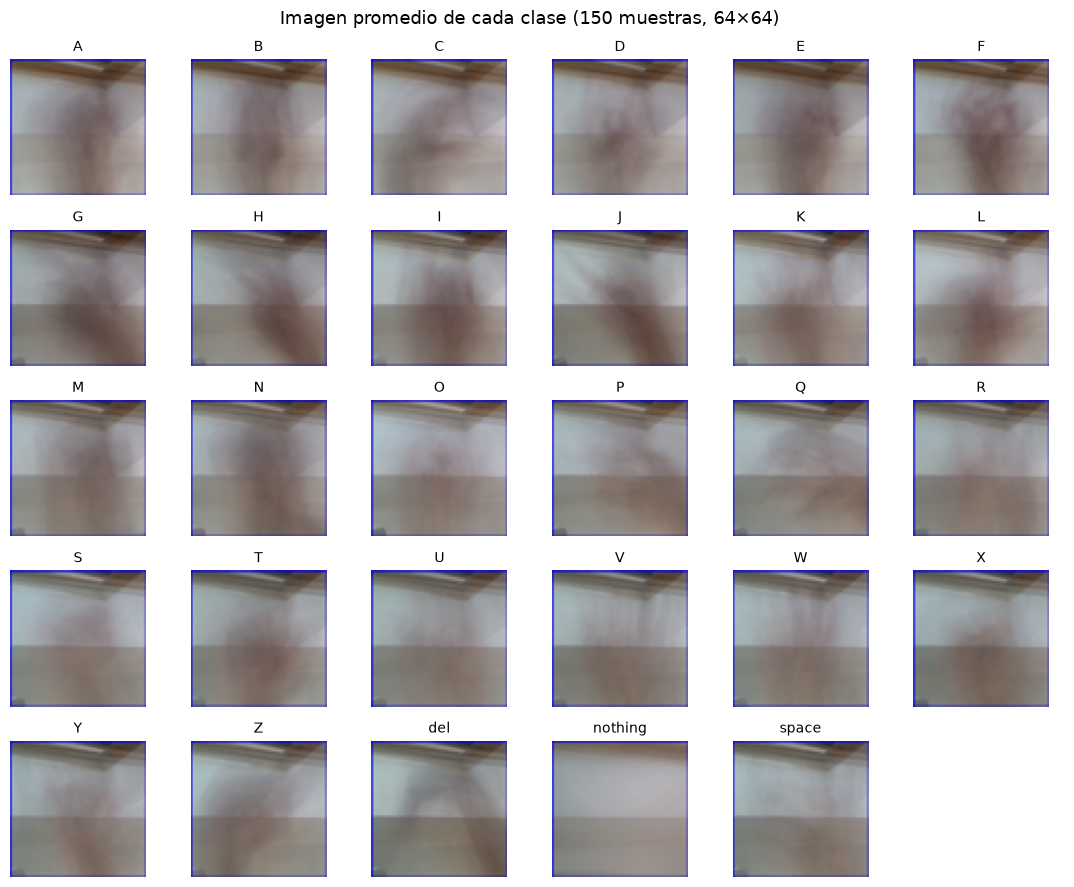

In [6]:
def promedio_clase(clase, n=150, size=64):
    acum = np.zeros((size, size, 3), dtype=np.float64)
    rutas = cargar_muestras(clase, n)
    for ruta in rutas:
        with Image.open(ruta) as im:
            acum += np.asarray(im.resize((size, size)), dtype=np.float64)
    return acum / len(rutas)

# Imagen promedio de cada una de las 29 clases (puede tardar ~1 min)
promedios = {c: promedio_clase(c) for c in CLASES}

fig, axes = plt.subplots(5, 6, figsize=(11, 9))
for ax, clase in zip(axes.ravel(), CLASES):
    ax.imshow(promedios[clase].astype("uint8"))
    ax.set_title(clase, fontsize=10)
    ax.axis("off")
for ax in axes.ravel()[len(CLASES):]:
    ax.axis("off")
fig.suptitle("Imagen promedio de cada clase (150 muestras, 64×64)", fontsize=13)
plt.tight_layout()
plt.show()

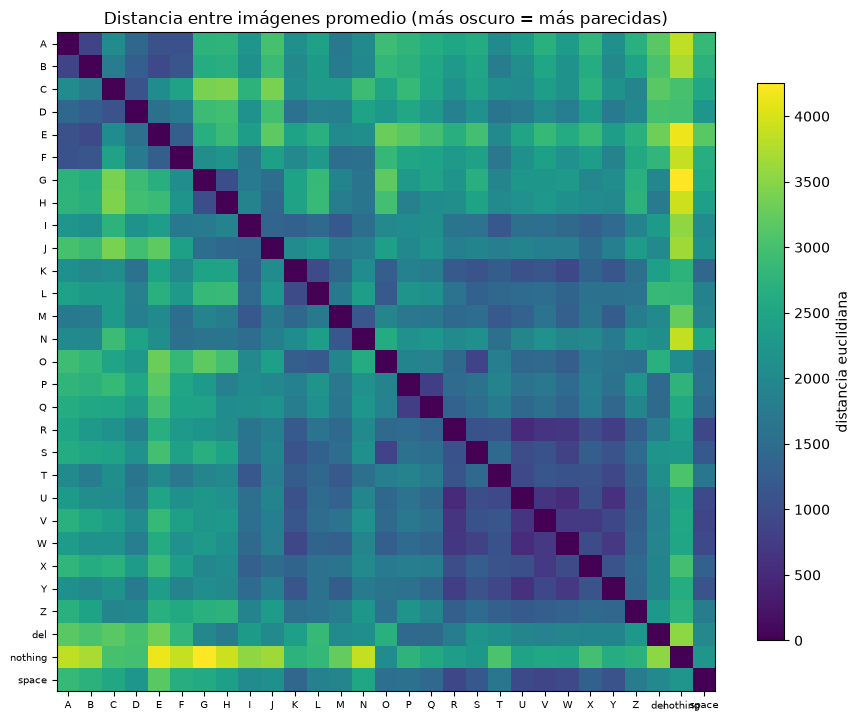

Los 12 pares de clases MÁS parecidos visualmente:
      R ~ U      distancia =    530.9
      U ~ W      distancia =    534.3
      U ~ Y      distancia =    609.5
      R ~ V      distancia =    635.9
      U ~ V      distancia =    658.6
      R ~ W      distancia =    682.1
      V ~ W      distancia =    698.1
      W ~ Y      distancia =    698.9
      V ~ X      distancia =    720.2
      R ~ Y      distancia =    782.0
      P ~ Q      distancia =    783.4
      S ~ W      distancia =    832.1


In [7]:
from scipy.spatial.distance import squareform, pdist

# Vector aplanado de cada imagen promedio -> matriz de distancias euclidianas
M = np.stack([promedios[c].ravel() for c in CLASES])
D = squareform(pdist(M, metric="euclidean"))

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(D, cmap="viridis")
ax.set_xticks(range(len(CLASES))); ax.set_xticklabels(CLASES, fontsize=7)
ax.set_yticks(range(len(CLASES))); ax.set_yticklabels(CLASES, fontsize=7)
ax.set_title("Distancia entre imágenes promedio (más oscuro = más parecidas)")
fig.colorbar(im, ax=ax, shrink=0.8, label="distancia euclidiana")
plt.tight_layout()
plt.show()

# Pares más parecidos (menor distancia), excluyendo la diagonal
Dtmp = D.copy(); np.fill_diagonal(Dtmp, np.inf)
pares = []
for i in range(len(CLASES)):
    for j in range(i + 1, len(CLASES)):
        pares.append((D[i, j], CLASES[i], CLASES[j]))
pares.sort()
print("Los 12 pares de clases MÁS parecidos visualmente:")
for d, a, b in pares[:12]:
    print(f"  {a:>5} ~ {b:<5}  distancia = {d:8.1f}")

Observamos de cerca los dos grupos clásicos de confusión que menciona el enunciado —
**M / N / S** (puño cerrado con el pulgar en distintas posiciones) y **U / V / R** (dos dedos
extendidos, juntos o cruzados):


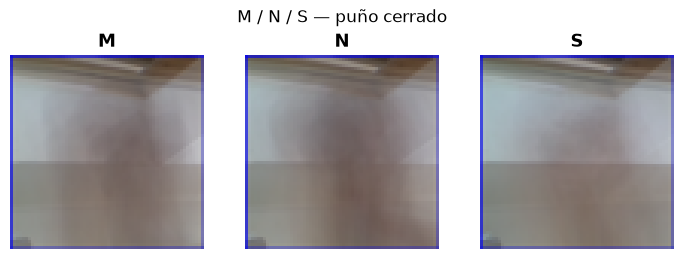

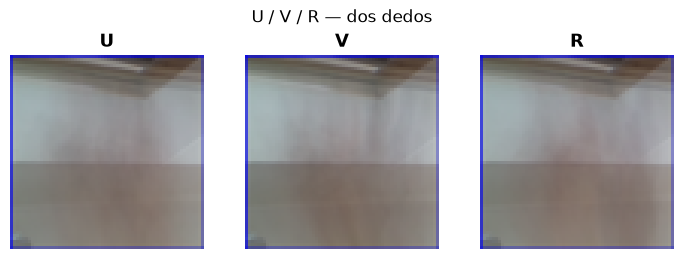

In [8]:
for grupo, titulo in [(["M", "N", "S"], "M / N / S — puño cerrado"),
                      (["U", "V", "R"], "U / V / R — dos dedos")]:
    fig, axes = plt.subplots(1, len(grupo), figsize=(len(grupo) * 2.4, 2.6))
    for ax, clase in zip(axes, grupo):
        ax.imshow(promedios[clase].astype("uint8"))
        ax.set_title(clase, fontsize=13, fontweight="bold")
        ax.axis("off")
    fig.suptitle(titulo, fontsize=12)
    plt.tight_layout()
    plt.show()

**Hallazgo.** La matriz de distancias y la lista de pares más cercanos identifican los
grupos de letras que serán la principal fuente de error del modelo. El más claro:

- **U / V / R** — el clúster **más parecido de todo el dataset** (aparecen juntos en el top de
  pares, con distancias ~530–660). Las tres muestran **dos dedos extendidos** y se distinguen
  solo por si están juntos (U), separados (V) o cruzados (R): un detalle fino que a baja
  resolución casi se pierde. Se les suman **W** e **Y** (manos abiertas de silueta parecida).
- **M / N / S** — el grupo clásico de **puño cerrado** que difieren solo en la posición del
  pulgar. Ojo con un matiz de método: en la *imagen promedio* su distancia es **moderada**
  (M–N ≈ 1150, N–S ≈ 2140), **mayor** que la de U/V/R. No es que se parezcan poco, sino que
  el promedio de píxeles está dominado por la posición y la iluminación de la mano, no por el
  detalle del pulgar —que es justamente lo que distingue estas letras—. Es decir, la
  confusión M/N/S es real por la **estructura de la seña**, aunque una métrica de píxel crudo
  la subestime.

Esto nos anticipa **dónde** mirar la matriz de confusión al entrenar, y advierte que **bajar
demasiado la resolución** borraría justo los detalles finos (pulgar, cruce de dedos) que
separan estas letras — un argumento para no reducir por debajo de ~64×64.


### 3.4 ¿Cómo definimos entrenamiento / validación / prueba?

El **set de prueba oficial** de Kaggle trae solo ~1 imagen por clase (28 en total) — es
demasiado pequeño para evaluar de forma confiable, y de hecho el enunciado nos pide construir
nuestro propio conjunto de prueba a partir de los datos de entrenamiento.

**Estrategia (estratificada por clase, semilla fija):** de las 3,000 imágenes de cada clase
las repartimos así, manteniendo la proporción **idéntica en todas las clases**:

| Partición | Proporción | Uso |
|-----------|-----------|-----|
| Entrenamiento | 70 % | ajustar los pesos del modelo |
| Validación | 15 % | elegir hiperparámetros / early stopping |
| Prueba (test) | 15 % | estimación final e imparcial del desempeño |

El *split* es **estratificado** (misma proporción por clase, así el balance se conserva en
las tres particiones) y **reproducible** (semilla fija). La partición concreta —junto con el
submuestreo por cómputo— se materializa en el preprocesamiento (Ejercicio 3).


In [9]:
from sklearn.model_selection import train_test_split

# Ilustramos el split con los CONTEOS por clase (aún sin cargar imágenes a memoria).
# Usamos 3000 por clase; en el Ej. 3 aplicamos el mismo esquema sobre la submuestra.
n_por_clase = 3000
idx = np.arange(n_por_clase)
tr, tmp = train_test_split(idx, test_size=0.30, random_state=SEED)
val, te = train_test_split(tmp, test_size=0.50, random_state=SEED)

reparto = pd.DataFrame({
    "por_clase": [len(tr), len(val), len(te)],
    "total_29_clases": [len(tr) * len(CLASES), len(val) * len(CLASES), len(te) * len(CLASES)],
}, index=["train (70%)", "val (15%)", "test (15%)"])
reparto.loc["TOTAL"] = reparto.sum()
print(reparto.to_string())

             por_clase  total_29_clases
train (70%)       2100            60900
val (15%)          450            13050
test (15%)         450            13050
TOTAL             3000            87000


**Hallazgo.** Con el esquema 70/15/15 sobre las 3,000 imágenes por clase tendríamos
~2,100 / 450 / 450 por clase (≈60,900 / 13,050 / 13,050 en total). En el preprocesamiento
reduciremos este volumen con una **submuestra por clase** para que el entrenamiento sea
viable en el tiempo del laboratorio, **conservando el mismo split estratificado** para no
mezclar imágenes entre particiones.


## 4. Ejercicio 3 — Preprocesamiento de las imágenes

Con lo aprendido en el EDA, definimos el preprocesamiento que aplicaremos **antes de
entrenar**. Tres decisiones, cada una justificada con un hallazgo del análisis exploratorio:

| Paso | Decisión | Justificación (del EDA) |
|------|----------|--------------------------|
| **Submuestreo** | 600 imágenes por clase (de 3,000) | 87,000 imágenes a color son inviables en el tiempo del lab; 600×29 = 17,400 mantiene el balance y es suficiente para entrenar. |
| **Resolución** | Reescalar 200×200 → **64×64** | Aligera el cómputo ~10×, pero **no bajamos de 64** porque el EDA mostró que a menor resolución se pierden los detalles finos (pulgar en M/N/S, cruce de dedos en U/V/R). |
| **Normalización** | Píxeles a rango **[0, 1]** (÷255) | Estabiliza y acelera el entrenamiento de las redes neuronales. |

No hace falta homogeneizar tamaños ni convertir modos: el EDA (3.1) confirmó que **todas** las
imágenes ya son 200×200 RGB.


### 4.1 Reducción de resolución: ¿por qué 64×64 y no menos?

Comparamos una misma imagen a distintas resoluciones para verlo con nuestros propios ojos.
Elegimos una **U** (parte del grupo confundible U/V/R), donde el detalle de los dedos es lo
que la distingue.


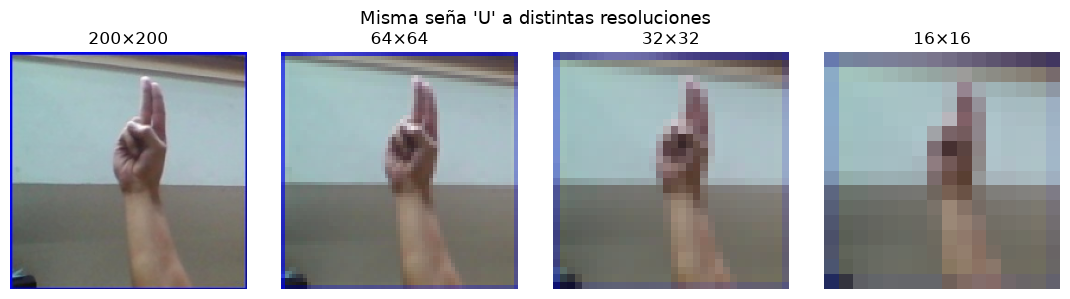

In [10]:
ejemplo = cargar_muestras("U", 1)[0]
orig = Image.open(ejemplo)

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, s in zip(axes, [200, 64, 32, 16]):
    ax.imshow(orig.resize((s, s)))
    ax.set_title(f"{s}×{s}", fontsize=12)
    ax.axis("off")
fig.suptitle("Misma seña 'U' a distintas resoluciones", fontsize=13)
plt.tight_layout()
plt.show()

**Hallazgo.** A **64×64** los dos dedos de la U siguen siendo claramente distinguibles; a
**32×32** empiezan a fundirse y a **16×16** ya es casi imposible saber cuántos dedos hay. Por
eso fijamos **64×64** como punto de equilibrio entre costo de cómputo y conservar la
información que separa las letras difíciles. La imagen sigue siendo a color (3 canales): el
tono no distingue letras, pero mantener RGB no añade costo relevante y evita perder textura.


### 4.2 Normalización a [0, 1]

Los píxeles vienen como enteros de 0 a 255. Los llevamos a flotantes en [0, 1] dividiendo
entre 255 — el rango que esperan las redes neuronales para entrenar de forma estable.


In [11]:
arr_uint8 = np.asarray(orig.resize((64, 64)))
arr_norm = arr_uint8.astype("float32") / 255.0
print("Antes  (uint8)  -> dtype:", arr_uint8.dtype, "| min:", arr_uint8.min(), "| max:", arr_uint8.max())
print("Después(float32)-> dtype:", arr_norm.dtype,  "| min:", arr_norm.min(),  "| max:", round(float(arr_norm.max()), 3))

Antes  (uint8)  -> dtype: uint8 | min: 5 | max: 242
Después(float32)-> dtype: float32 | min: 0.019607844 | max: 0.949


### 4.3 Construcción de los conjuntos train / val / test

Materializamos el plan definido en el EDA (3.4): tomamos 600 imágenes por clase, las
reescalamos a 64×64 y aplicamos el **split estratificado 70/15/15** (mismo balance por clase,
semilla fija). Guardamos los arreglos como **uint8** en un caché `.npz` (ignorado por git) para
que la entrega final reutilice el preprocesamiento sin recalcularlo; la normalización a [0,1]
se aplica al momento de entrenar, para no duplicar el tamaño en disco.


In [12]:
IMG_SIZE = 64
N_POR_CLASE = 600
CACHE = "../data/processed/asl_64.npz"

if os.path.exists(CACHE):
    d = np.load(CACHE)
    X, y = d["X"], d["y"]
    print(f"Caché encontrado: {CACHE}")
else:
    X_list, y_list = [], []
    for etiqueta, clase in enumerate(CLASES):
        for ruta in cargar_muestras(clase, N_POR_CLASE):
            with Image.open(ruta) as im:
                X_list.append(np.asarray(im.resize((IMG_SIZE, IMG_SIZE)), dtype=np.uint8))
            y_list.append(etiqueta)
    X = np.stack(X_list)
    y = np.array(y_list, dtype=np.int16)
    os.makedirs(os.path.dirname(CACHE), exist_ok=True)
    np.savez_compressed(CACHE, X=X, y=y)
    print(f"Dataset construido y cacheado en {CACHE}")

print(f"X: {X.shape}  ({X.dtype})   |   y: {y.shape}   |   clases: {len(np.unique(y))}")
print(f"Memoria de X (uint8): {X.nbytes / 1e6:.0f} MB")

Caché encontrado: ../data/processed/asl_64.npz
X: (17400, 64, 64, 3)  (uint8)   |   y: (17400,)   |   clases: 29
Memoria de X (uint8): 214 MB


In [13]:
from sklearn.model_selection import train_test_split

# Split estratificado 70/15/15 (reproducible). stratify=y conserva el balance por clase.
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

resumen = pd.DataFrame({
    "imágenes": [len(y_tr), len(y_val), len(y_te)],
    "img/clase": [len(y_tr)//len(CLASES), len(y_val)//len(CLASES), len(y_te)//len(CLASES)],
    "forma_X": [str(X_tr.shape[1:]), str(X_val.shape[1:]), str(X_te.shape[1:])],
}, index=["train (70%)", "val (15%)", "test (15%)"])
print(resumen.to_string())
print("\n¿Balance conservado en train? min/clase =",
      pd.Series(y_tr).value_counts().min(), "| max/clase =",
      pd.Series(y_tr).value_counts().max())

             imágenes  img/clase      forma_X
train (70%)     12180        420  (64, 64, 3)
val (15%)        2610         90  (64, 64, 3)
test (15%)       2610         90  (64, 64, 3)

¿Balance conservado en train? min/clase = 420 | max/clase = 420


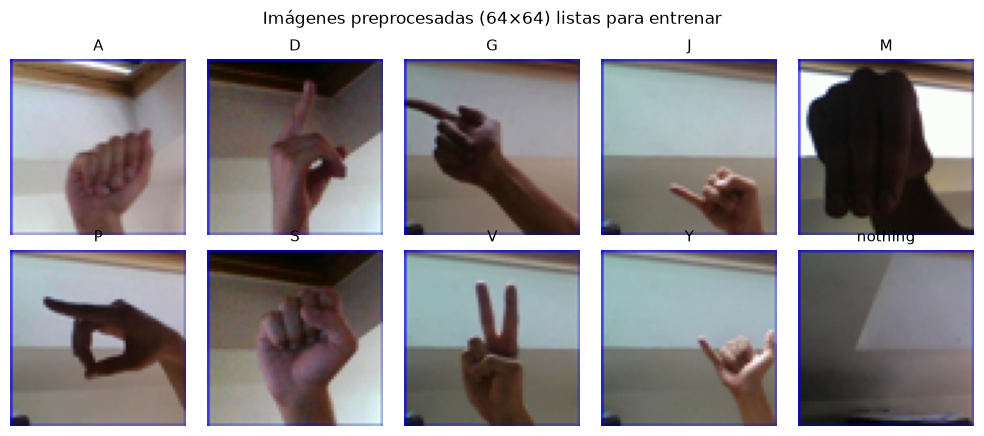

In [14]:
# Verificación visual: una muestra ya preprocesada (64x64) de 10 clases distintas
fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for ax, etiqueta in zip(axes.ravel(), range(0, len(CLASES), 3)):
    i = np.where(y_tr == etiqueta)[0][0]
    ax.imshow(X_tr[i])
    ax.set_title(CLASES[etiqueta], fontsize=11)
    ax.axis("off")
fig.suptitle("Imágenes preprocesadas (64×64) listas para entrenar", fontsize=12)
plt.tight_layout()
plt.show()

**Resumen del preprocesamiento.** Partimos de 17,400 imágenes (600 × 29) reescaladas a
64×64×3 y las repartimos en **train / val / test estratificados** (~420 / 90 / 90 por clase),
conservando el balance perfecto. Los arreglos quedan cacheados en disco para la entrega final.
La normalización a [0, 1] se aplicará dentro del pipeline de cada modelo.


## 5. Selección de modelos y plan para el procesamiento de imágenes

Con los datos ya explorados y preprocesados, dejamos definido **qué modelos construiremos** en
la entrega final y **cómo fluirán las imágenes** hacia cada uno. La rúbrica pide comparar
varias familias de modelos, así que elegimos una de cada tipo:


### 5.1 Modelos a construir

| # | Modelo | Entrada | Por qué / qué esperamos |
|---|--------|---------|--------------------------|
| **CNN A (base)** | 2 bloques Conv+MaxPool + capa densa | 64×64×3 en [0,1] | Referencia CNN sencilla. Las convoluciones detectan bordes y formas de la mano de forma invariante a la posición — ideal para este problema. |
| **CNN B (profunda)** | 3 bloques Conv + BatchNorm + Dropout | 64×64×3 en [0,1] | Más capacidad y regularización para separar las clases difíciles (U/V/R, M/N/S). Esperamos que sea **el mejor** modelo. |
| **Red densa simple** | Flatten → 2 capas densas | 12,288 valores (64·64·3) | Ejercicio 5: baseline de red *fully-connected*. Al aplanar pierde la estructura espacial, así que esperamos que rinda **peor** que las CNN — justo lo que queremos demostrar. |
| **Otro algoritmo: Random Forest** | Imagen aplanada (opcional PCA) | vector de píxeles | Ejercicio 6: modelo clásico, rápido de entrenar, robusto y sin necesidad de GPU. Sirve de baseline no-neuronal. Alternativa considerada: SVM con PCA. |

**Métricas y comparación.** Para todos usaremos **accuracy** (confiable por el balance
perfecto), además de **matriz de confusión** y **reporte por clase** (precision/recall), con
atención especial a los grupos U/V/R y M/N/S que el EDA marcó como confundibles. El "mejor
modelo" se elige por accuracy en **validación**; la estimación final se reporta sobre **test**.


---
# Parte II — Entrega final: Modelado

Desde aquí desarrollamos y evaluamos los modelos (Ejercicios 4–9). Todo es **reproducible**:
los modelos se reentrenan corriendo estas celdas de arriba hacia abajo; los artefactos pesados
(`.keras`) quedan fuera de git, pero las métricas, curvas y matrices de confusión quedan
**incrustadas en el notebook**.

## 6. Preparación de los datos para entrenar

Reutilizamos el split estratificado del §4.3 y aplicamos la **normalización** a [0, 1]
(pendiente del preprocesamiento) más el **one-hot** de las etiquetas que necesitan las redes.


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

# Normalización a [0,1] (de uint8 -> float32) reutilizando el split del §4.3
X_train = X_tr.astype("float32") / 255.0
X_valid = X_val.astype("float32") / 255.0
X_test  = X_te.astype("float32") / 255.0

NUM_CLASES = len(CLASES)
y_train_oh = keras.utils.to_categorical(y_tr,  NUM_CLASES)
y_valid_oh = keras.utils.to_categorical(y_val, NUM_CLASES)
y_test_oh  = keras.utils.to_categorical(y_te,  NUM_CLASES)

print(f"X_train: {X_train.shape}  dtype={X_train.dtype}  rango=[{X_train.min():.0f}, {X_train.max():.0f}]")
print(f"X_valid: {X_valid.shape}   X_test: {X_test.shape}")
print(f"y one-hot: {y_train_oh.shape}  ({NUM_CLASES} clases)")

TensorFlow: 2.21.0


X_train: (12180, 64, 64, 3)  dtype=float32  rango=[0, 1]
X_valid: (2610, 64, 64, 3)   X_test: (2610, 64, 64, 3)
y one-hot: (12180, 29)  (29 clases)


### 6.1 Utilidades reutilizables y línea base

Definimos dos ayudantes que usarán **todos** los modelos —curvas de aprendizaje y evaluación
(accuracy + matriz de confusión + reporte por clase)— y un diccionario `resultados` donde
iremos acumulando el accuracy de cada modelo para la **comparación final**. Como el dataset
está perfectamente balanceado, la **línea base de azar** es 1/29 ≈ 3.4%: cualquier modelo útil
debe superarla con holgura.


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Grupos que el EDA marcó como visualmente confundibles (para vigilarlos al evaluar)
GRUPOS_CONFUSION = {"U/V/R": ["U", "V", "R"], "M/N/S": ["M", "N", "S"]}
resultados = {}  # nombre_modelo -> accuracy en test

def graficar_curvas(history, titulo=""):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(h["accuracy"], label="train")
    axes[0].plot(h["val_accuracy"], label="val")
    axes[0].set_title(f"Accuracy · {titulo}"); axes[0].set_xlabel("época"); axes[0].legend()
    axes[1].plot(h["loss"], label="train")
    axes[1].plot(h["val_loss"], label="val")
    axes[1].set_title(f"Pérdida · {titulo}"); axes[1].set_xlabel("época"); axes[1].legend()
    plt.tight_layout(); plt.show()

def evaluar(y_true, y_pred, nombre, registrar=True):
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy de '{nombre}' en test: {acc:.4f}  (baseline azar = {1/NUM_CLASES:.3f})")
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(9, 7.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASES)); ax.set_xticklabels(CLASES, fontsize=7, rotation=90)
    ax.set_yticks(range(NUM_CLASES)); ax.set_yticklabels(CLASES, fontsize=7)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión · {nombre}")
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()

    # Enfoque en los grupos confundibles detectados en el EDA
    for grupo, letras in GRUPOS_CONFUSION.items():
        idx = [CLASES.index(l) for l in letras]
        sub = cm[np.ix_(idx, idx)]
        aciertos = np.trace(sub); total = sub.sum()
        print(f"  Grupo {grupo}: {aciertos}/{total} correctas dentro del grupo "
              f"({aciertos/total:.1%})")
    if registrar:
        resultados[nombre] = acc
    return acc

print("Utilidades listas. Modelos registrados hasta ahora:", list(resultados))

Utilidades listas. Modelos registrados hasta ahora: []


**Nota de método.** `evaluar()` no solo reporta el accuracy global: dibuja la matriz de
confusión completa y, además, mide cuántas predicciones se quedan *dentro* de los grupos
**U/V/R** y **M/N/S**. Así conectamos cada modelo con la hipótesis del análisis exploratorio y
podremos comprobar si de verdad esos grupos son los que más cuestan.


## 7. Ejercicio 4 — Modelos de redes neuronales convolucionales (CNN)

Las **CNN** son la familia natural para este problema: sus filtros convolucionales detectan
bordes y formas de la mano de manera **invariante a la posición**, justo lo que necesitamos
cuando la mano aparece a distintas distancias y encuadres. Entrenaremos **dos** arquitecturas
y nos quedaremos con la mejor.

### 7.1 CNN A — modelo base

Arquitectura sencilla de referencia: **dos bloques Conv + MaxPooling** seguidos de una cabeza
densa. Nos da un punto de partida contra el cual medir mejoras.

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

def construir_cnn_a():
    modelo = models.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(NUM_CLASES, activation="softmax"),
    ], name="CNN_A")
    modelo.compile(optimizer="adam",
                   loss="categorical_crossentropy",
                   metrics=["accuracy"])
    return modelo

cnn_a = construir_cnn_a()
cnn_a.summary()

Model: "CNN_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,628,893 (6.21 MB)

 Trainable params: 1,628,893 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Entrenamiento con early stopping (restaura los mejores pesos por val_accuracy)
os.makedirs("../models", exist_ok=True)   # carpeta ignorada por git (.keras es pesado)

es = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
hist_a = cnn_a.fit(
    X_train, y_train_oh,
    validation_data=(X_valid, y_valid_oh),
    epochs=20, batch_size=128,
    callbacks=[es], verbose=2,
)
cnn_a.save("../models/cnn_a.keras")
print("Modelo guardado en ../models/cnn_a.keras (no se versiona; se reentrena con estas celdas)")

Epoch 1/20


96/96 - 5s - 54ms/step - accuracy: 0.1948 - loss: 2.8926 - val_accuracy: 0.3483 - val_loss: 2.2372


Epoch 2/20


96/96 - 4s - 45ms/step - accuracy: 0.4899 - loss: 1.7338 - val_accuracy: 0.5835 - val_loss: 1.4135


Epoch 3/20


...

Epoch 11/20


96/96 - 4s - 46ms/step - accuracy: 0.9789 - loss: 0.0921 - val_accuracy: 0.8602 - val_loss: 0.4970


Epoch 12/20


96/96 - 4s - 46ms/step - accuracy: 0.9791 - loss: 0.0828 - val_accuracy: 0.8628 - val_loss: 0.5029


Modelo guardado en ../models/cnn_a.keras (no se versiona; se reentrena con estas celdas)


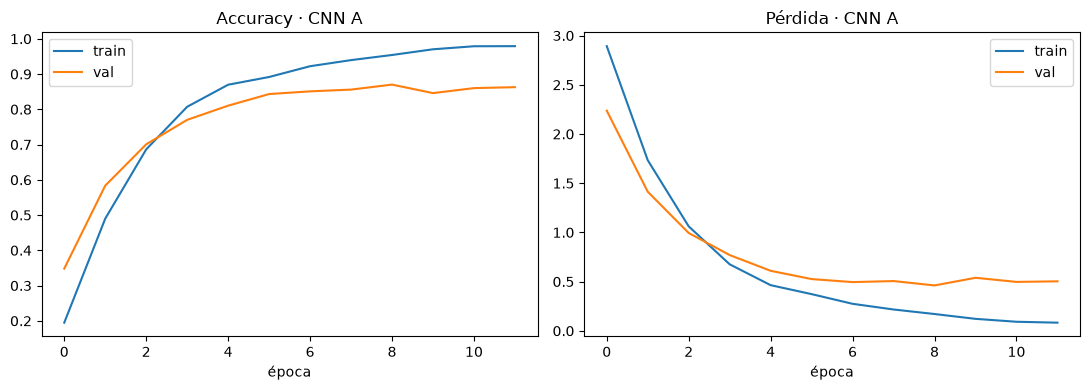

In [19]:
graficar_curvas(hist_a, "CNN A")

Accuracy de 'CNN A' en test: 0.8602  (baseline azar = 0.034)


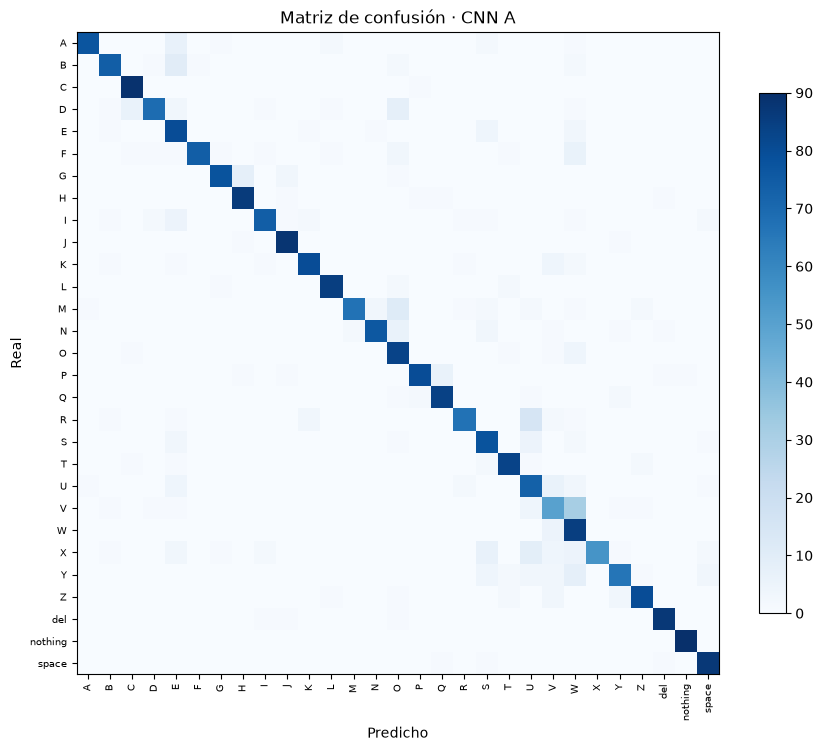

  Grupo U/V/R: 190/219 correctas dentro del grupo (86.8%)
  Grupo M/N/S: 221/231 correctas dentro del grupo (95.7%)


0.8601532567049809

In [20]:
pred_a = cnn_a.predict(X_test, verbose=0).argmax(axis=1)
evaluar(y_te, pred_a, "CNN A")

**Interpretación — CNN A.** La CNN base alcanza **86.0% de accuracy en test**, muy por encima
de la línea base de azar (3.4%). Observaciones:

- **Sobreajuste moderado.** Las curvas muestran que el accuracy de *train* sube hasta ~98% y la
  *pérdida* de train sigue bajando, mientras que la validación se estanca en ~86% desde la
  época 6–7 (early stopping restauró los pesos de la mejor época). Esa brecha train–val indica
  que el modelo está **memorizando** parte del entrenamiento. Es justo lo que atacaremos en la
  CNN B con **Dropout y BatchNorm**.
- **Los errores coinciden con el EDA.** Dentro del grupo **U/V/R** solo el **86.8%** se clasifica
  bien, frente al **95.7%** de **M/N/S**. El grupo de "dos dedos" (U/V/R) —el más parecido según
  la matriz de distancias del §3.3— es efectivamente el que más confunde al modelo, confirmando
  la hipótesis del análisis exploratorio.

CNN A queda como referencia: buena, pero con margen claro de mejora en regularización y en las
letras difíciles. Eso motiva la **CNN B**.